# 06 — Structural analysis: per-triad Ramachandran + global summaries

Three sets of figures characterizing AF3 structural prediction quality on the
16 class I validation triads (Fig 4a).

Addresses **Reviewer 1 Major Points #1 and #2** (dihedral-coordinate metrics,
PTI-PAE as a quality proxy).

## What's here
1. **Per-triad Ramachandran** — AF3 prediction vs PDB crystal, side-by-side
2. **Ramachandran TV distance vs PTI-PAE** — per-triad summary (no correlation,
   because reverse-dock failures have low local TV despite high RMSD)
3. **CDR RMSD vs (31 - PTI-PAE)** — per-triad summary (negative correlation: higher 31-PTI-PAE -> lower RMSD)
4. **Ramachandran TV vs CDR RMSD** — direct comparison of the two metrics

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde, pearsonr, spearmanr

CDR_COLORS = {'cdr1': '#1f77b4', 'cdr2': '#2ca02c',
              'cdr2_5': '#ff7f0e', 'cdr3': '#d62728'}
CDR_LABELS = {'cdr1': 'CDR1', 'cdr2': 'CDR2', 'cdr2_5': 'CDR2.5', 'cdr3': 'CDR3'}
CHAIN_MARKERS = {'tcr_1': ('o', 'α'), 'tcr_2': ('^', 'β')}

df = pd.read_csv('ramachandran_all_classI.csv')
print(f'{len(df)} rows across {df["pdb"].nunique()} PDBs')
print(f'PDB codes: {sorted(df["pdb"].unique())}')

996 rows across 16 PDBs
PDB codes: ['7q99', '7q9a', '7q9b', '8dnt', '8en8', '8enh', '8eo8', '8es9', '8f5a', '8gom', '8gon', '8i5c', '8i5d', '8wte', '8wul', '8ye4']


## (1) Per-triad Ramachandran plot

Change `TARGET_PDB` below to any of the 16 PDB codes to render that triad.

Saved: rama_7q9a_topo.png


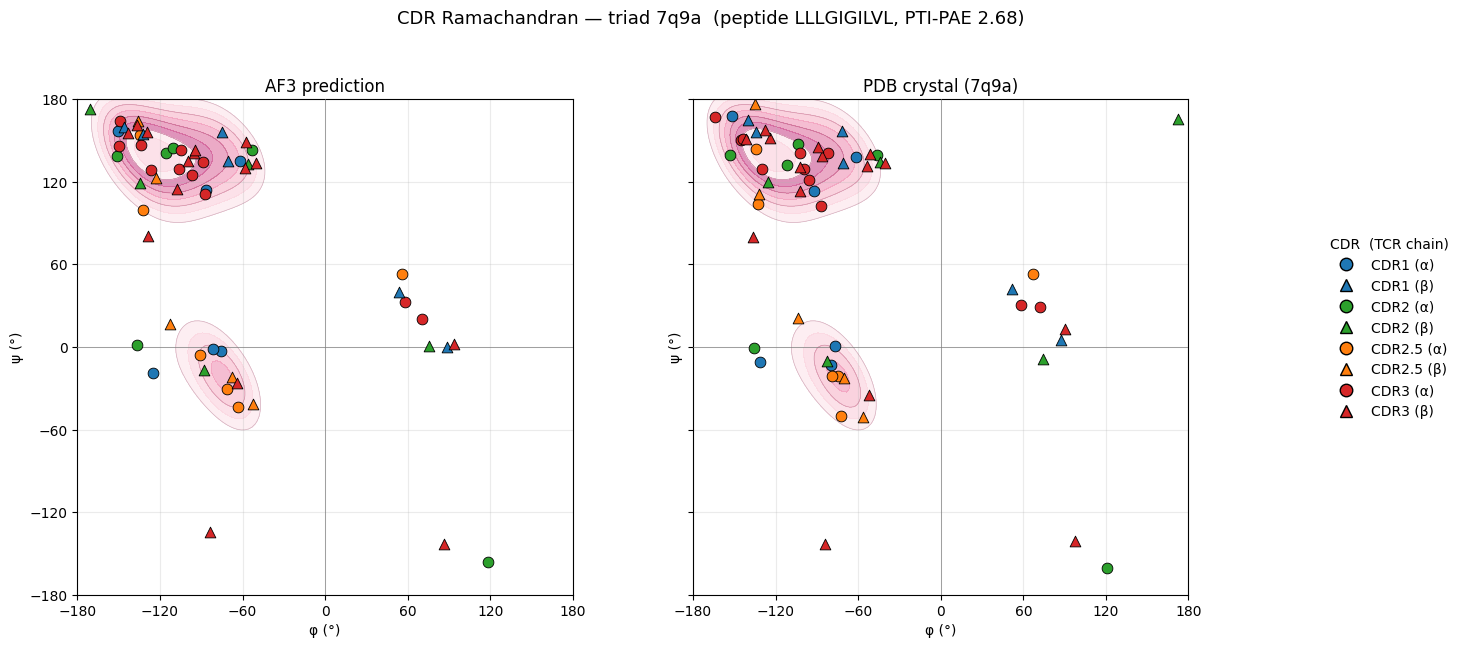

In [2]:
TARGET_PDB = '7q9a'   # ← change this and re-run

def make_kde_background(phi_vals, psi_vals, grid_n=140):
    xy = np.vstack([phi_vals, psi_vals])
    kde = gaussian_kde(xy, bw_method=0.25)
    grid = np.linspace(-180, 180, grid_n)
    XX, YY = np.meshgrid(grid, grid)
    positions = np.vstack([XX.ravel(), YY.ravel()])
    ZZ = kde(positions).reshape(XX.shape)
    return XX, YY, ZZ

def render_panel(ax, sub_df, phi_col, psi_col, XX, YY, ZZ, title):
    levels = np.linspace(ZZ.min(), ZZ.max(), 12)[3:]
    ax.contourf(XX, YY, ZZ, levels=levels,
                colors=['#fde0e8','#fbcad8','#f7adc4','#ee87ad','#dc6498','#c63d83'],
                alpha=0.55, zorder=1, extend='neither')
    ax.contour(XX, YY, ZZ, levels=levels[::2],
                colors=['#88375a'], alpha=0.35, linewidths=0.5, zorder=2)
    for chain, (marker, _) in CHAIN_MARKERS.items():
        for cdr, color in CDR_COLORS.items():
            mask = (sub_df['tcr'] == chain) & (sub_df['cdr'] == cdr)
            ax.scatter(sub_df.loc[mask, phi_col], sub_df.loc[mask, psi_col],
                       marker=marker, s=60, color=color,
                       edgecolors='black', linewidths=0.6, zorder=5)
    ax.set_xlim(-180, 180); ax.set_ylim(-180, 180)
    ax.set_xlabel('φ (°)'); ax.set_ylabel('ψ (°)')
    ax.set_xticks(np.arange(-180, 181, 60)); ax.set_yticks(np.arange(-180, 181, 60))
    ax.axhline(0, color='0.5', lw=0.5, zorder=3)
    ax.axvline(0, color='0.5', lw=0.5, zorder=3)
    ax.grid(True, alpha=0.25, zorder=0)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12)


sub = df[df['pdb'] == TARGET_PDB].copy()
peptide = sub['peptide'].iloc[0]
pti_pae = sub['pti_pae'].iloc[0]

pool = df.dropna(subset=['phi_crystal', 'psi_crystal'])
XX, YY, ZZ = make_kde_background(pool['phi_crystal'].values,
                                  pool['psi_crystal'].values, grid_n=140)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
render_panel(axes[0], sub, 'phi_pred', 'psi_pred', XX, YY, ZZ, 'AF3 prediction')
render_panel(axes[1], sub, 'phi_crystal', 'psi_crystal', XX, YY, ZZ,
             f'PDB crystal ({TARGET_PDB})')
fig.suptitle(f'CDR Ramachandran — triad {TARGET_PDB}  '
             f'(peptide {peptide}, PTI-PAE {pti_pae:.2f})',
             fontsize=13, y=0.99)

handles = []
for cdr in ['cdr1', 'cdr2', 'cdr2_5', 'cdr3']:
    color = CDR_COLORS[cdr]
    for chain, (marker, gly) in CHAIN_MARKERS.items():
        handles.append(Line2D([0], [0], marker=marker, color='w',
                               markerfacecolor=color, markeredgecolor='black',
                               markersize=9, label=f'{CDR_LABELS[cdr]} ({gly})'))
fig.legend(handles=handles, loc='center right', frameon=False,
            title='CDR  (TCR chain)', title_fontsize=10, fontsize=10,
            bbox_to_anchor=(1.0, 0.5))
plt.tight_layout(rect=(0, 0, 0.86, 0.96))
fig.savefig(f'rama_{TARGET_PDB}_topo.png', dpi=300, bbox_inches='tight')
print(f'Saved: rama_{TARGET_PDB}_topo.png')
plt.show()

## (2) Compute per-triad TV/JS distances

For each triad, compares the KDE of predicted (φ,ψ) against the KDE of crystal
(φ,ψ) across all CDR residues.

In [3]:
GRID_N = 60
phi_grid = np.linspace(-180, 180, GRID_N)
psi_grid = np.linspace(-180, 180, GRID_N)
PHI, PSI = np.meshgrid(phi_grid, psi_grid)
positions = np.vstack([PHI.ravel(), PSI.ravel()])
cell_area = (phi_grid[1] - phi_grid[0]) * (psi_grid[1] - psi_grid[0])

def wrap180(d):
    """Wrap angle difference into [-180, 180]."""
    return ((d + 180.0) % 360.0) - 180.0

rows = []
for pdb, g in df.groupby('pdb'):
    g = g.dropna(subset=['phi_pred','psi_pred','phi_crystal','psi_crystal'])
    if len(g) < 5:
        continue

    # --- mean per-residue dihedral distance (degrees) ---
    dphi = wrap180(g['phi_pred'].values - g['phi_crystal'].values)
    dpsi = wrap180(g['psi_pred'].values - g['psi_crystal'].values)
    per_res = np.sqrt(dphi**2 + dpsi**2)        # L2 in (phi, psi), degrees
    mean_dihedral = float(per_res.mean())

    # --- TV / JS via KDE (kept for backward compatibility) ---
    pred_kde = gaussian_kde(np.vstack([g['phi_pred'], g['psi_pred']]), bw_method=0.25)
    crys_kde = gaussian_kde(np.vstack([g['phi_crystal'], g['psi_crystal']]), bw_method=0.25)
    p_dens = pred_kde(positions).reshape(PHI.shape)
    c_dens = crys_kde(positions).reshape(PHI.shape)
    p_dens /= (p_dens.sum() * cell_area)
    c_dens /= (c_dens.sum() * cell_area)
    tv = 0.5 * np.abs(p_dens - c_dens).sum() * cell_area
    m = 0.5 * (p_dens + c_dens)
    eps = 1e-12
    kl_pm = (p_dens * np.log((p_dens + eps) / (m + eps))).sum() * cell_area
    kl_cm = (c_dens * np.log((c_dens + eps) / (m + eps))).sum() * cell_area
    js = 0.5 * (kl_pm + kl_cm)

    rows.append({'pdb': pdb,
                 'peptide': g['peptide'].iloc[0],
                 'pti_pae': float(g['pti_pae'].iloc[0]),
                 'mean_dihedral_deg': mean_dihedral,
                 'tv': float(tv), 'js': float(js), 'n': int(len(g))})

rama_df = pd.DataFrame(rows).sort_values('pti_pae')
rama_df.to_csv('ramachandran_distances_per_triad.csv', index=False)
print(rama_df.to_string(index=False))


 pdb    peptide   pti_pae  mean_dihedral_deg       tv       js  n
8enh  LPFEKSTIM  2.191815          45.534387 0.168057 0.045959 66
8eo8  LPFDKATIM  2.208889          36.569576 0.184550 0.039883 66
8dnt  LLLDRLNQL  2.225886          45.422311 0.302674 0.094692 60
7q9b EAAGIGILTV  2.645462          26.866888 0.211486 0.048116 58
7q9a LLLGIGILVL  2.683656           8.042374 0.093157 0.012748 60
8en8  LPFDKSTIM  2.739923          44.298111 0.199796 0.050389 66
7q99 NLSALGIFST  3.065067          12.901814 0.128069 0.019079 60
8gon  RLQSLQIYV  5.949677           9.160540 0.070105 0.005365 63
8i5d  VVGAVGVGK  6.123334          27.076490 0.148039 0.031850 61
8wul  VVGAVGVGK  6.544630          37.905225 0.204447 0.037231 63
8i5c  VVGAVGVGK  7.141587          30.557727 0.170748 0.036173 59
8ye4  NYNYLYRLF  7.410085          37.013283 0.160034 0.032863 62
8f5a TSTLQEQIGW  8.068840          46.316850 0.122065 0.023428 62
8gom  RLQSLQTYV  8.365555          11.737298 0.106276 0.017842 63
8wte  VVGA

## (3) Ramachandran TV vs PTI-PAE

mean per-residue dihedral distance vs AF3 PTI-PAE  (n=16)
  Pearson  r=-0.166  p=0.538
  Spearman ρ=-0.088  p=0.745


Saved: plot_ramachandran_vs_pae.png


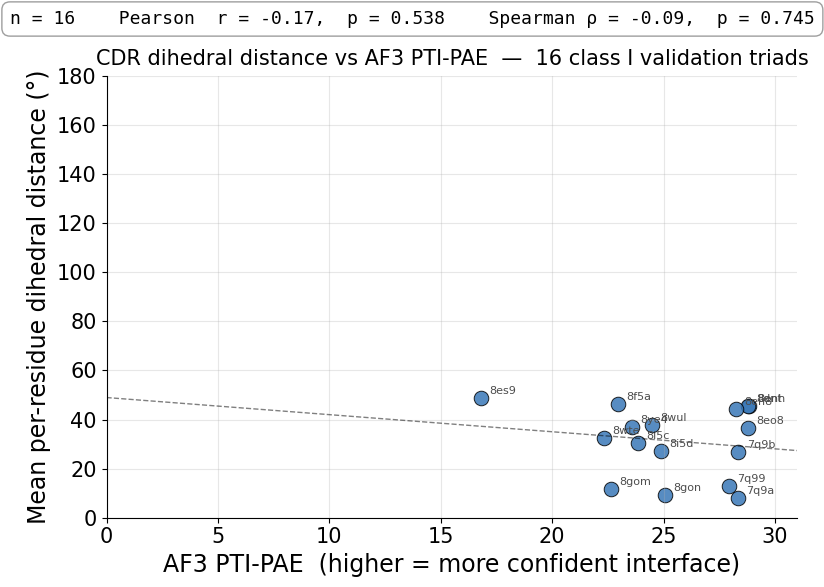

In [4]:
rama_df = rama_df.copy()
rama_df['pti_pae_31'] = 31 - rama_df['pti_pae']
ycol = 'mean_dihedral_deg'

r_pearson, p_pearson = pearsonr(rama_df['pti_pae_31'], rama_df[ycol])
r_spearman, p_spearman = spearmanr(rama_df['pti_pae_31'], rama_df[ycol])
print(f'mean per-residue dihedral distance vs AF3 PTI-PAE  (n={len(rama_df)})')
print(f'  Pearson  r={r_pearson:+.3f}  p={p_pearson:.3f}')
print(f'  Spearman \u03c1={r_spearman:+.3f}  p={p_spearman:.3f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(rama_df['pti_pae_31'], rama_df[ycol], s=110, color='#3a78b8',
           edgecolors='black', linewidths=0.7, alpha=0.85)
for _, row in rama_df.iterrows():
    ax.annotate(row['pdb'], (row['pti_pae_31'], row[ycol]),
                xytext=(6, 3), textcoords='offset points', fontsize=8, color='0.3')

slope, intercept = np.polyfit(rama_df['pti_pae_31'], rama_df[ycol], 1)
xs = np.linspace(0, 31, 50)
ax.plot(xs, slope * xs + intercept, 'k--', alpha=0.5, lw=1)

ax.set_xlabel('AF3 PTI-PAE  (higher = more confident interface)', fontsize=17)
ax.set_ylabel('Mean per-residue dihedral distance (\u00b0)', fontsize=17)
ax.set_title(f'CDR dihedral distance vs AF3 PTI-PAE  \u2014  {len(rama_df)} class I validation triads',
             fontsize=15, pad=8)
ax.set_xlim(0, 31)
ax.set_ylim(0, 180)
ax.tick_params(labelsize=15)

# stats text in the figure top margin (outside the axes)
stats = (f"n = {len(rama_df)}    "
         f"Pearson  r = {r_pearson:+.2f},  p = {p_pearson:.3f}    "
         f"Spearman \u03c1 = {r_spearman:+.2f},  p = {p_spearman:.3f}")
fig.text(0.5, 0.97, stats, ha='center', va='top', fontsize=13, family='monospace',
         bbox=dict(facecolor='white', edgecolor='0.6', boxstyle='round,pad=0.45', alpha=0.95))

ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.subplots_adjust(top=0.86)
fig.savefig('plot_ramachandran_vs_pae.png', dpi=300, bbox_inches='tight')
print('Saved: plot_ramachandran_vs_pae.png')
plt.show()


## (3b) L¹ dihedral distance vs AF3 PTI-PAE (full theoretical range)

Loaded 996 residues across 16 triads


 pdb  pti_pae_raw  dihed_L1  n_residues  pti_pae_31
8enh     2.191815 53.219947          66   28.808185
8eo8     2.208889 43.246224          66   28.791111
8dnt     2.225886 55.419876          60   28.774114
7q9b     2.645462 32.190520          58   28.354538
7q9a     2.683656 10.024901          60   28.316344
8en8     2.739923 50.997970          66   28.260077
7q99     3.065067 16.434022          60   27.934933
8gon     5.949677 11.827122          63   25.050323
8i5d     6.123334 32.998127          61   24.876666
8wul     6.544630 47.754604          63   24.455370
8i5c     7.141587 37.363550          59   23.858413
8ye4     7.410085 44.701370          62   23.589915
8f5a     8.068840 55.931685          62   22.931160
8gom     8.365555 14.376699          63   22.634445
8wte     8.668366 38.115663          63   22.331634
8es9    14.217999 60.082222          64   16.782001

Pearson  r = -0.196   p = 0.468
Spearman ρ = -0.094   p = 0.729



Saved -> plot_dihedral_L1_vs_pae.png


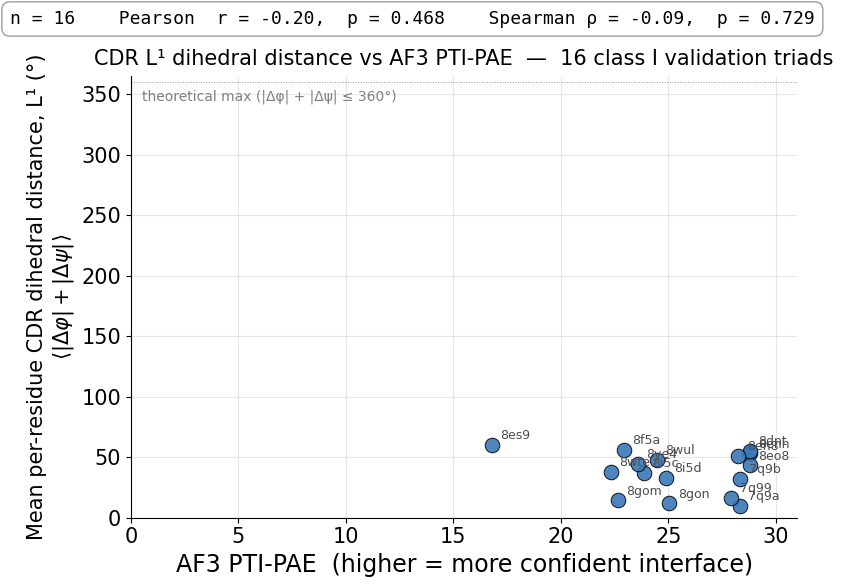

In [5]:
# Per-residue L1 dihedral distance: |Δφ| + |Δψ| (theoretical max = 360°).
# Same data as cell 5 / cell 7 but with the L1 distance metric and a y-axis
# fixed to the full 0–360° range so the absolute scale of error is visible.

INPUT_CSV  = 'ramachandran_all_classI.csv'
OUTPUT_PNG = 'plot_dihedral_L1_vs_pae.png'
CLASS_COLOR = '#3a78b8'   # class I blue, consistent with the rest of the package

raw = pd.read_csv(INPUT_CSV)
print(f'Loaded {len(raw)} residues across {raw["pdb"].nunique()} triads')

def circ_deg(a, b):
    return np.abs((a - b + 180.0) % 360.0 - 180.0)

raw['dphi'] = circ_deg(raw['phi_pred'], raw['phi_crystal'])
raw['dpsi'] = circ_deg(raw['psi_pred'], raw['psi_crystal'])
raw['d_L1'] = raw['dphi'] + raw['dpsi']

per_triad = (raw.groupby('pdb')
                .agg(pti_pae_raw=('pti_pae', 'first'),
                     dihed_L1=('d_L1', 'mean'),
                     n_residues=('d_L1', 'size'))
                .reset_index())
per_triad['pti_pae_31'] = 31 - per_triad['pti_pae_raw']   # convention: high = better
per_triad = per_triad.sort_values('pti_pae_31', ascending=False)

print(per_triad.to_string(index=False))

r_p, p_p = pearsonr(per_triad['pti_pae_31'], per_triad['dihed_L1'])
r_s, p_s = spearmanr(per_triad['pti_pae_31'], per_triad['dihed_L1'])
print(f'\nPearson  r = {r_p:+.3f}   p = {p_p:.3f}')
print(f'Spearman \u03c1 = {r_s:+.3f}   p = {p_s:.3f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(per_triad['pti_pae_31'], per_triad['dihed_L1'],
           s=110, edgecolor='black', linewidth=0.7,
           color=CLASS_COLOR, alpha=0.9, zorder=3)
for _, row in per_triad.iterrows():
    ax.annotate(row['pdb'], (row['pti_pae_31'], row['dihed_L1']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=9, color='0.3')

# theoretical-max reference line
ax.axhline(360, color='gray', lw=0.7, ls=':', alpha=0.8)
ax.text(0.5, 354, 'theoretical max (|\u0394\u03c6| + |\u0394\u03c8| \u2264 360\u00b0)',
        ha='left', va='top', fontsize=10, color='gray')

ax.set_xlim(0, 31)
ax.set_ylim(0, 365)
ax.set_xlabel('AF3 PTI-PAE  (higher = more confident interface)', fontsize=17)
ax.set_ylabel('Mean per-residue CDR dihedral distance, L\u00b9 (\u00b0)\n'
              r'$\langle |\Delta\varphi| + |\Delta\psi| \rangle$',
              fontsize=15)
ax.set_title(f'CDR L\u00b9 dihedral distance vs AF3 PTI-PAE  \u2014  '
             f'{len(per_triad)} class I validation triads',
             fontsize=15, pad=8)
ax.tick_params(labelsize=15)

stats = (f"n = {len(per_triad)}    "
         f"Pearson  r = {r_p:+.2f},  p = {p_p:.3f}    "
         f"Spearman \u03c1 = {r_s:+.2f},  p = {p_s:.3f}")
fig.text(0.5, 0.97, stats, ha='center', va='top', fontsize=13, family='monospace',
         bbox=dict(facecolor='white', edgecolor='0.6', boxstyle='round,pad=0.45', alpha=0.95))

ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.subplots_adjust(top=0.86)
fig.savefig(OUTPUT_PNG, dpi=300, bbox_inches='tight')
print(f'\nSaved -> {OUTPUT_PNG}')
plt.show()


## (3c) L¹ dihedral distance vs CDR RMSD (two structural metrics)

Loaded 996 residues across 16 triads
 pdb  dihed_L1  n_residues  cdr_rmsd
8enh 53.219947          66  1.209166
8en8 50.997970          66  1.302022
7q99 16.434022          60  1.305301
8eo8 43.246224          66  1.309609
7q9a 10.024901          60  1.755917
8i5d 32.998127          61  1.886481
8dnt 55.419876          60  2.235925
8wte 38.115663          63  2.855849
8wul 47.754604          63  3.093435
8f5a 55.931685          62  3.458406
8ye4 44.701370          62  4.381153
8i5c 37.363550          59  4.542551
8es9 60.082222          64 17.912052
7q9b 32.190520          58 21.285000
8gom 14.376699          63 22.805682
8gon 11.827122          63 23.857141

Pearson  r = -0.346   p = 0.189
Spearman ρ = -0.206   p = 0.444



Saved -> plot_dihedral_L1_vs_rmsd.png


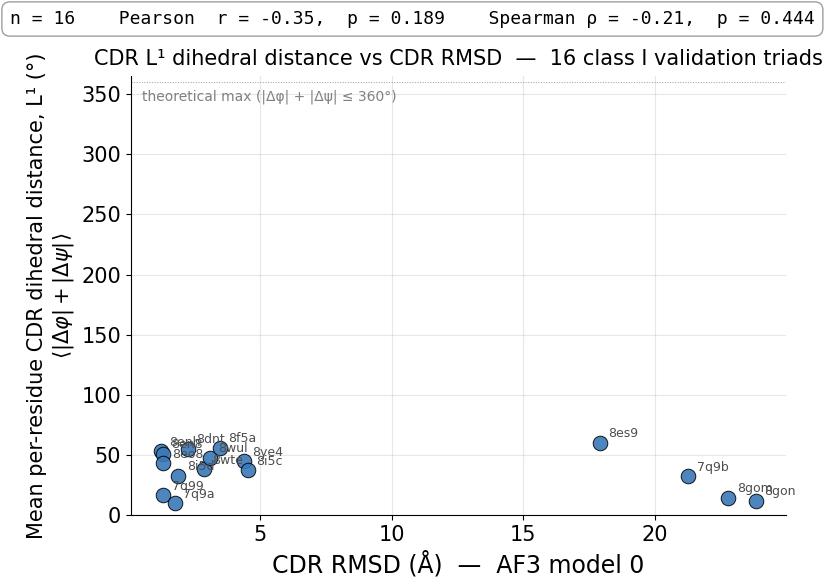

In [6]:
# Per-residue L1 dihedral distance vs CDR RMSD — directly comparing the two
# structural-accuracy metrics on the same 16 triads. CDR RMSDs are AF3 model 0
# (seed-0). 15 of the values come from cdr_rmsd_af3_0 in
# pdb_triad.af3_rmsd.parquet; 7q9b was computed standalone (parquet pipeline
# failed on it).

INPUT_CSV   = 'ramachandran_all_classI.csv'
OUTPUT_PNG  = 'plot_dihedral_L1_vs_rmsd.png'
CLASS_COLOR = '#3a78b8'   # class I blue, consistent with the rest of the package

CDR_RMSD = {
    "7q99": 1.305301, "7q9a": 1.755917, "7q9b": 21.285000,
    "8dnt": 2.235925, "8en8": 1.302022, "8enh": 1.209166,
    "8eo8": 1.309609, "8es9": 17.912052, "8f5a": 3.458406,
    "8gom": 22.805682, "8gon": 23.857141, "8i5c": 4.542551,
    "8i5d": 1.886481, "8wte": 2.855849, "8wul": 3.093435, "8ye4": 4.381153,
}

raw = pd.read_csv(INPUT_CSV)
print(f'Loaded {len(raw)} residues across {raw["pdb"].nunique()} triads')

def circ_deg(a, b):
    return np.abs((a - b + 180.0) % 360.0 - 180.0)

raw['dphi'] = circ_deg(raw['phi_pred'], raw['phi_crystal'])
raw['dpsi'] = circ_deg(raw['psi_pred'], raw['psi_crystal'])
raw['d_L1'] = raw['dphi'] + raw['dpsi']

per_triad = (raw.groupby('pdb')
                .agg(dihed_L1=('d_L1', 'mean'),
                     n_residues=('d_L1', 'size'))
                .reset_index())
per_triad['cdr_rmsd'] = per_triad['pdb'].map(CDR_RMSD)
per_triad = per_triad.dropna(subset=['cdr_rmsd']).sort_values('cdr_rmsd')

print(per_triad.to_string(index=False))

r_p, p_p = pearsonr(per_triad['cdr_rmsd'], per_triad['dihed_L1'])
r_s, p_s = spearmanr(per_triad['cdr_rmsd'], per_triad['dihed_L1'])
print(f'\nPearson  r = {r_p:+.3f}   p = {p_p:.3f}')
print(f'Spearman \u03c1 = {r_s:+.3f}   p = {p_s:.3f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(per_triad['cdr_rmsd'], per_triad['dihed_L1'],
           s=110, edgecolor='black', linewidth=0.7,
           color=CLASS_COLOR, alpha=0.9, zorder=3)
for _, row in per_triad.iterrows():
    ax.annotate(row['pdb'], (row['cdr_rmsd'], row['dihed_L1']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=9, color='0.3')

ax.axhline(360, color='gray', lw=0.7, ls=':', alpha=0.8)
ax.text(0.5, 354, 'theoretical max (|\u0394\u03c6| + |\u0394\u03c8| \u2264 360\u00b0)',
        ha='left', va='top', fontsize=10, color='gray')

ax.set_ylim(0, 365)
ax.set_xlabel('CDR RMSD (\u00c5)  \u2014  AF3 model 0', fontsize=17)
ax.set_ylabel('Mean per-residue CDR dihedral distance, L\u00b9 (\u00b0)\n'
              r'$\langle |\Delta\varphi| + |\Delta\psi| \rangle$',
              fontsize=15)
ax.set_title(f'CDR L\u00b9 dihedral distance vs CDR RMSD  \u2014  '
             f'{len(per_triad)} class I validation triads',
             fontsize=15, pad=8)
ax.tick_params(labelsize=15)

stats = (f"n = {len(per_triad)}    "
         f"Pearson  r = {r_p:+.2f},  p = {p_p:.3f}    "
         f"Spearman \u03c1 = {r_s:+.2f},  p = {p_s:.3f}")
fig.text(0.5, 0.97, stats, ha='center', va='top', fontsize=13, family='monospace',
         bbox=dict(facecolor='white', edgecolor='0.6', boxstyle='round,pad=0.45', alpha=0.95))

ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.subplots_adjust(top=0.86)
fig.savefig(OUTPUT_PNG, dpi=300, bbox_inches='tight')
print(f'\nSaved -> {OUTPUT_PNG}')
plt.show()


## (4) CDR RMSD vs (31 - PTI-PAE)

All 16 class I validation triads are populated (the 16th, 7q9b, is included).

Result: Pearson r = -0.53 (p = 0.036), Spearman ρ = -0.60 (p = 0.014) — higher
31-PTI-PAE (more confident interface) goes with lower CDR RMSD.

CDR RMSD vs (31 - PTI-PAE)  (n=16)
  Pearson  r=-0.527  p=0.036
  Spearman ρ=-0.600  p=0.014


Saved: plot_rmsd_vs_pae.png


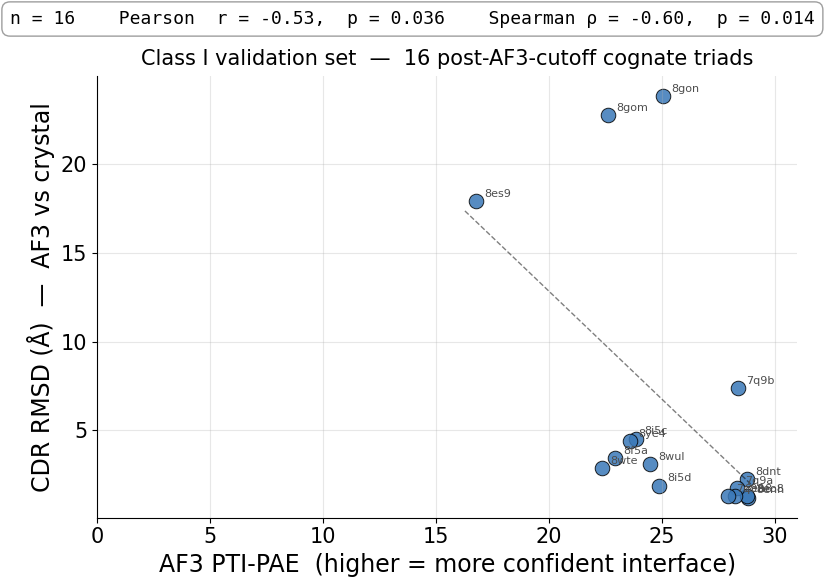

In [7]:
merged = pd.read_csv('merged_tv_rmsd_pae.csv')
have_rmsd = merged.dropna(subset=['cdr_rmsd']).copy()
have_rmsd['pti_pae_31'] = 31 - have_rmsd['pti_pae']

if len(have_rmsd) >= 3:
    r_pearson, p_pearson = pearsonr(have_rmsd['pti_pae_31'], have_rmsd['cdr_rmsd'])
    r_spearman, p_spearman = spearmanr(have_rmsd['pti_pae_31'], have_rmsd['cdr_rmsd'])
    print(f'CDR RMSD vs (31 - PTI-PAE)  (n={len(have_rmsd)})')
    print(f'  Pearson  r={r_pearson:+.3f}  p={p_pearson:.3f}')
    print(f'  Spearman \u03c1={r_spearman:+.3f}  p={p_spearman:.3f}')

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(have_rmsd['pti_pae_31'], have_rmsd['cdr_rmsd'], s=110, color='#3a78b8',
               edgecolors='black', linewidths=0.7, alpha=0.85)
    for _, row in have_rmsd.iterrows():
        ax.annotate(row['pdb'], (row['pti_pae_31'], row['cdr_rmsd']),
                    xytext=(6, 3), textcoords='offset points', fontsize=8, color='0.3')
    slope, intercept = np.polyfit(have_rmsd['pti_pae_31'], have_rmsd['cdr_rmsd'], 1)
    xs = np.linspace(have_rmsd['pti_pae_31'].min() - 0.5, have_rmsd['pti_pae_31'].max() + 0.5, 50)
    ax.plot(xs, slope * xs + intercept, 'k--', alpha=0.5, lw=1)
    ax.set_xlabel('AF3 PTI-PAE  (higher = more confident interface)', fontsize=17)
    ax.set_ylabel('CDR RMSD (\u00c5)  \u2014  AF3 vs crystal', fontsize=17)
    ax.set_title(f'Class I validation set  \u2014  {len(have_rmsd)} post-AF3-cutoff cognate triads',
                 fontsize=15, pad=8)
    ax.set_xlim(0, 31)
    ax.tick_params(labelsize=15)
    # stats text moved OUTSIDE the axes (figure margin, top-left) so no overlap with data
    stats = (f"n = {len(have_rmsd)}    "
             f"Pearson  r = {r_pearson:+.2f},  p = {p_pearson:.3f}    "
             f"Spearman \u03c1 = {r_spearman:+.2f},  p = {p_spearman:.3f}")
    fig.text(0.5, 0.97, stats, ha='center', va='top', fontsize=13, family='monospace',
             bbox=dict(facecolor='white', edgecolor='0.6', boxstyle='round,pad=0.45', alpha=0.95))
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.subplots_adjust(top=0.86)
    fig.savefig('plot_rmsd_vs_pae.png', dpi=300, bbox_inches='tight')
    print('Saved: plot_rmsd_vs_pae.png')
    plt.show()
else:
    print('cdr_rmsd column not populated in merged_tv_rmsd_pae.csv.')

## Interpretation

- **Ramachandran TV is NOT correlated with (31 - PTI-PAE)** (Pearson r ≈ -0.03, p ≈ 0.93) —
  because it is invariant to the rigid-body "reverse-dock" failures
  (8gom, 8gon) that drive most of the RMSD spread.
- **CDR RMSD IS correlated with (31 - PTI-PAE)** (Pearson r ≈ -0.53, p ≈ 0.036;
  Spearman ρ ≈ -0.60, p ≈ 0.014) — the failure mode is rigid-body misplacement,
  and a low 31-PTI-PAE successfully flags those cases.

Together: AF3 generally gets local CDR torsion conformations right, even when
its global rigid-body docking is wrong. The per-triad plot for 8gom is a clean
visual of this: nearly-perfect (φ,ψ) agreement, despite the global pose being
wrong (reverse-docked).